**Feature Engineering**

- So far we have performed feature analysis

    - Data Frame quick checks

    - Categorical column analysis

    - Bar charts, pie charts

    - Numerical column analysis

    - Histograms, box plots, outliers

    - Bi-multi variate analysis

    - Correlation etc

- Now we need to learn Feature Engineering

    - we will create a new columns for better ML models

    - we wll perform the **Encoding**, which is convert categorical to Numerical data

    - we will do data **transformations**

    - we will perform **Scaling: Standardization and Normalization**

    - we will perform the **missing value analysis**

- Simply feature engineering means our data will be modified

**11-12-2025**

- Feature Analysis

- Feature Engineering

- Feature Selection

- Model Development

- Model Evaluation

- Model Tuning

- Model Deployment

**Encoding**

- Encoding means convert categorical data to numerical data

- ML/DL or any models works based on mathematics 

- Models cannot understand english characters

- So it is very important to convert categorical label to numerical values

- For Example Gender column has two labels

    - Male

    - Female

- Then Female represents as 0, Male represent as 1 based o Alphabetical order

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
visa_df=pd.read_csv('Visadataset.csv')
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [3]:
cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns

In [4]:
visa_df['case_status'].unique()

array(['Denied', 'Certified'], dtype=object)

- Certified should assign as 0

- Denied should assign as 1

In [5]:
# mapping

d={'Certified':0,
   'Denied':1}
d

{'Certified': 0, 'Denied': 1}

In [6]:
visa_df['case_status']

0           Denied
1        Certified
2           Denied
3           Denied
4        Certified
           ...    
25475    Certified
25476    Certified
25477    Certified
25478    Certified
25479    Certified
Name: case_status, Length: 25480, dtype: object

In [7]:
# convert the Certified to 0 and denied to 1 using mapping
visa_df['case_status'].map(d)

0        1
1        0
2        1
3        1
4        0
        ..
25475    0
25476    0
25477    0
25478    0
25479    0
Name: case_status, Length: 25480, dtype: int64

In [8]:
visa_df['case_status']=visa_df['case_status'].map(d)

In [9]:
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,1
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,0
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,1
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,1
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,0
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,0
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,0
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,0
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,0


In [ ]:
# if you are getting Nan you ran double times
# so do one by one from starting
# read the data
# select the columns
# create a mapper
# map to selected column

In [10]:
visa_df['continent'].unique()

array(['Asia', 'Africa', 'North America', 'Europe', 'South America',
       'Oceania'], dtype=object)

In [11]:
# create a dictionary
d={}
d['Asia']=0
d['Africa']=1
d['North America']=2
d['Europe']=3
d['South America']=4
d['Oceania']=5
d

# d[i]=j

{'Asia': 0,
 'Africa': 1,
 'North America': 2,
 'Europe': 3,
 'South America': 4,
 'Oceania': 5}

In [12]:
labels=visa_df['continent'].unique()
n=len(labels)
dic={}

for i in range(n):
    dic[labels[i]]=i
dic


{'Asia': 0,
 'Africa': 1,
 'North America': 2,
 'Europe': 3,
 'South America': 4,
 'Oceania': 5}

In [13]:
visa_df['continent'].map(dic)

0        0
1        0
2        0
3        0
4        1
        ..
25475    0
25476    0
25477    0
25478    0
25479    0
Name: continent, Length: 25480, dtype: int64

In [14]:
visa_df['continent']=visa_df['continent'].map(dic)

In [15]:
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,0,High School,N,N,14513,2007,West,592.2029,Hour,Y,1
1,EZYV02,0,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,0
2,EZYV03,0,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,1
3,EZYV04,0,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,1
4,EZYV05,1,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,0
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,0,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,0
25476,EZYV25477,0,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,0
25477,EZYV25478,0,Master's,Y,N,1121,1910,South,146298.8500,Year,N,0
25478,EZYV25479,0,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,0


In [16]:
# another method
labels=sorted(visa_df['continent'].unique())
d={}
for i,j in enumerate(labels):
    d[j]=i
d



{np.int64(0): 0,
 np.int64(1): 1,
 np.int64(2): 2,
 np.int64(3): 3,
 np.int64(4): 4,
 np.int64(5): 5}

In [ ]:
labels=sorted(visa_df['continent'].unique())
# dictionary comprehension
d={j:i  for i,j in enumerate(labels)}
visa_df['continent']=visa_df['continent'].map(d)

# i need to repeat above 3 lines for all cat columns
# except case_id

labels=sorted(visa_df[i].unique())
d={j:i  for i,j in enumerate(labels)}
visa_df[i]=visa_df[i].map(d)

In [17]:
# Step-1: read the data
# Step-2: get the cat columns
# then perform the above conversion
visa_df=pd.read_csv('Visadataset.csv')
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [18]:
cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns

In [19]:
for i in cat[1:]:
    labels=sorted(visa_df[i].unique())
    d={j:i  for i,j in enumerate(labels)}
    visa_df[i]=visa_df[i].map(d)
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,1,2,0,0,14513,2007,4,592.2029,0,1,1
1,EZYV02,1,3,1,0,2412,2002,2,83425.6500,3,1,0
2,EZYV03,1,0,0,1,44444,2008,4,122996.8600,3,1,1
3,EZYV04,1,0,0,0,98,1897,4,83434.0300,3,1,1
4,EZYV05,0,3,1,0,1082,2005,3,149907.3900,3,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,1,0,1,1,2601,2008,3,77092.5700,3,1,0
25476,EZYV25477,1,2,1,0,3274,2006,2,279174.7900,3,1,0
25477,EZYV25478,1,3,1,0,1121,1910,3,146298.8500,3,0,0
25478,EZYV25479,1,3,1,1,1918,1887,4,86154.7700,3,1,0


**LabelEncoder**

- LabelEncoder is a method will convert cat lables to numerical values

- It is under package: **sklearn (scikit-learn)**

    - The class Name : **preprocessing**
 
        - The Method name: **LabelEncoder**

In [20]:
import sklearn

In [21]:
# from <package>.<class> import <method>
from sklearn.preprocessing import LabelEncoder

- Step-1: import the method

- Step-2: save the method

- Step-3: apply fit transform

- **fit transform**

    - **fit**: means find the logic

        - in above example fit means create a **mapper** or **dict**

    - **transform**: means apply the logic and change the data

        - apply the **mapper on the data**

In [22]:
# read the data again
visa_df=pd.read_csv('Visadataset.csv')
cat=visa_df.select_dtypes(include='object').columns

# import the method
from sklearn.preprocessing import LabelEncoder

# save the method
le=LabelEncoder()

# apply fit transform
visa_df['case_status']=le.fit_transform(visa_df['case_status'])
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,1
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,0
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,1
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,1
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,0
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,0
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,0
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,0
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,0


In [23]:
# import the method
from sklearn.preprocessing import LabelEncoder

# save the method
le=LabelEncoder()

# apply fit transform
visa_df['continent']=le.fit_transform(visa_df['continent'])
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,1,High School,N,N,14513,2007,West,592.2029,Hour,Y,1
1,EZYV02,1,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,0
2,EZYV03,1,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,1
3,EZYV04,1,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,1
4,EZYV05,0,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,0
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,1,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,0
25476,EZYV25477,1,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,0
25477,EZYV25478,1,Master's,Y,N,1121,1910,South,146298.8500,Year,N,0
25478,EZYV25479,1,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,0


In [24]:
# read the data again
# get cat columns
# apply for loop on above logic

visa_df=pd.read_csv('Visadataset.csv')
cat=visa_df.select_dtypes(include='object').columns

from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in cat[1:]:
    visa_df[i]=le.fit_transform(visa_df[i])
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,1,2,0,0,14513,2007,4,592.2029,0,1,1
1,EZYV02,1,3,1,0,2412,2002,2,83425.6500,3,1,0
2,EZYV03,1,0,0,1,44444,2008,4,122996.8600,3,1,1
3,EZYV04,1,0,0,0,98,1897,4,83434.0300,3,1,1
4,EZYV05,0,3,1,0,1082,2005,3,149907.3900,3,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,1,0,1,1,2601,2008,3,77092.5700,3,1,0
25476,EZYV25477,1,2,1,0,3274,2006,2,279174.7900,3,1,0
25477,EZYV25478,1,3,1,0,1121,1910,3,146298.8500,3,0,0
25478,EZYV25479,1,3,1,1,1918,1887,4,86154.7700,3,1,0


**OneHotEncoder**

- first how many labels are there in a columns

- That many new columns will be created extra

- For example case status has two labels

    - Certified

    - Denied

- So it will create Two new extra columns

    - case_status_Certified

    - case_status_Denied

- At a time one column value become 1 other column value become 0

- This means a **One hot encoder**

|case_status|case_status_Certified|case_status_Denied|
|-|-|-|
|Certified|1|0|
|Denied|0|1|
|Denied|0|1|
|Certified|1|0|

In [ ]:
# continent     C_A       C_Af       C_E
# Asia           1          0         0
# Africa         0          1         0
# Europe         0          0         1

**pd.get_dummies**

In [25]:
visa_df=pd.read_csv('Visadataset.csv')
cat=visa_df.select_dtypes(include='object').columns

pd.get_dummies(visa_df['case_status'],dtype=int)

,Certified,Denied
0,0,1
1,1,0
2,0,1
3,0,1
4,1,0
...,...,...
25475,1,0
25476,1,0
25477,1,0
25478,1,0


In [26]:
pd.get_dummies(visa_df['continent'],dtype=int)

,Africa,Asia,Europe,North America,Oceania,South America
0,0,1,0,0,0,0
1,0,1,0,0,0,0
2,0,1,0,0,0,0
3,0,1,0,0,0,0
4,1,0,0,0,0,0
...,...,...,...,...,...,...
25475,0,1,0,0,0,0
25476,0,1,0,0,0,0
25477,0,1,0,0,0,0
25478,0,1,0,0,0,0


**12-12-2025**

- we have two types of scaling

    - Z score (Standardization)

    - Min max scalar (Normalization)

<img alt="" style="width: 162px; height: 132.2px; margin-top: 23.9px; margin-left: 0px;" class="" src="https://tse1.mm.bing.net/th/id/OIP.buxGjpIysxio0uiOWK_0rQAAAA?pid=Api&amp;P=0&amp;h=180" id="yui_3_5_1_1_1765511769529_835">

In [2]:
visa_df=pd.read_csv('Visadataset.csv')
cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns

In [3]:
# Step-1: take the pwage data
# Step-2: calculate mean of the data
# Step-3: calculate standard deviation of the data
# STep-4: nr = data-mean  ==> Step_1 - step_2
# Step-5: z_wage=nr/std   ==> step4/step3
# STep-6: create a new column visa_df['z_wage']=z_wage

pwage=visa_df['prevailing_wage']
Mean=pwage.mean()
std=pwage.std()
Nr=pwage - Mean
z_wage=Nr/std
visa_df['z_wage']=z_wage
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,z_wage
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,-1.398510
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,0.169832
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,0.919060
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,0.169991
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,1.428576
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified,0.049923
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified,3.876083
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified,1.360253
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified,0.221504


In [4]:
visa_df[['prevailing_wage','z_wage']]

,prevailing_wage,z_wage
0,592.2029,-1.398510
1,83425.6500,0.169832
2,122996.8600,0.919060
3,83434.0300,0.169991
4,149907.3900,1.428576
...,...,...
25475,77092.5700,0.049923
25476,279174.7900,3.876083
25477,146298.8500,1.360253
25478,86154.7700,0.221504


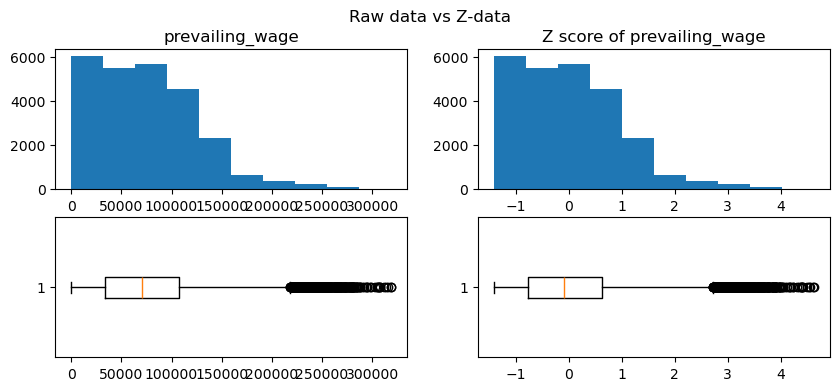

In [5]:
plt.figure(figsize=(10,4))
plt.suptitle('Raw data vs Z-data')
plt.subplot(2,2,1).hist(pwage)
plt.title('prevailing_wage')
plt.subplot(2,2,2).hist(z_wage)
plt.title('Z score of prevailing_wage')
plt.subplot(2,2,3).boxplot(pwage,vert=False)
plt.subplot(2,2,4).boxplot(z_wage,vert=False)
plt.show()

**StandardScalar**

- sklearn

  - preprocessing

      - StandardScalar

In [14]:
# Step-1: import method
# Step-2: save the method
# Step-3: apply fit transform
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit_transform(visa_df['prevailing_wage'])

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [15]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
wage_ss=ss.fit_transform(visa_df[['prevailing_wage']])
visa_df['wage_ss']=wage_ss

In [16]:
visa_df[['prevailing_wage','z_wage','wage_ss']]

,prevailing_wage,z_wage,wage_ss
0,592.2029,-1.398510,-1.398537
1,83425.6500,0.169832,0.169835
2,122996.8600,0.919060,0.919079
3,83434.0300,0.169991,0.169994
4,149907.3900,1.428576,1.428604
...,...,...,...
25475,77092.5700,0.049923,0.049924
25476,279174.7900,3.876083,3.876159
25477,146298.8500,1.360253,1.360280
25478,86154.7700,0.221504,0.221509


In [17]:
visa_df
visa_df['prevailing_wage']
visa_df['prevailing_wage'].values
visa_df[['prevailing_wage']]

,prevailing_wage
0,592.2029
1,83425.6500
2,122996.8600
3,83434.0300
4,149907.3900
...,...
25475,77092.5700
25476,279174.7900
25477,146298.8500
25478,86154.7700


In [18]:
visa_df
visa_df['prevailing_wage'].values

array([   592.2029,  83425.65  , 122996.86  , ..., 146298.85  ,
        86154.77  ,  70876.91  ])

In [19]:
visa_df['prevailing_wage'].values.reshape(-1,1)

array([[   592.2029],
       [ 83425.65  ],
       [122996.86  ],
       ...,
       [146298.85  ],
       [ 86154.77  ],
       [ 70876.91  ]])

In [21]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
wage_ss=ss.fit_transform(visa_df['prevailing_wage'].values.reshape(-1,1))
visa_df['wage_ss']=wage_ss
wage_ss

array([[-1.39853722],
       [ 0.1698353 ],
       [ 0.91907852],
       ...,
       [ 1.36027953],
       [ 0.22150859],
       [-0.06776315]])

**MinMaxScalar**

In [ ]:
# Step-1: read the data
# Step-2: calculate min
# Step-3: calculate max
# Step-4: Nr=step1-step2
# Step-5: Dr=Step3-Step2
# Step-6: Nr/Dr
# Step-7: visa_df['wage_min_max']=Nr/Dr

In [11]:
pwage=visa_df['prevailing_wage']
Min=pwage.min()
Max=pwage.max()
Nr=pwage-Min
Dr=Max-Min
visa_df['wage_min_max']=Nr/Dr
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,z_wage,wage_min_max
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,-1.398510,0.001849
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,0.169832,0.261345
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,0.919060,0.385312
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,0.169991,0.261371
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,1.428576,0.469616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified,0.049923,0.241505
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified,3.876083,0.874579
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified,1.360253,0.458311
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified,0.221504,0.269895


In [13]:
max(Nr/Dr),min(Nr/Dr)

(1.0, 0.0)

In [8]:
import sklearn

In [9]:
from sklearn.preprocessing import MinMaxScaler
mms=MinMaxScaler()
mms.fit_transform(visa_df['prevailing_wage'].values.reshape(-1,1))

array([[0.00184853],
       [0.2613452 ],
       [0.385312  ],
       ...,
       [0.45831136],
       [0.26989486],
       [0.22203311]])